<a href="https://colab.research.google.com/github/ramyamail2-collab/Facial-Emotion-Recognition-using-OpenCV-and-Deepface/blob/main/number_plate_cv_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Install required libraries and Tesseract OCR engine (added for self-contained execution)
!pip install pytesseract
!sudo apt update
!sudo apt install tesseract-ocr
!pip install matplotlib-venn
!apt-get -qq install -y libfluidsynth1
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot
!pip install cartopy
import cartopy

import cv2
import pytesseract
import numpy as np
import re
from datetime import datetime

# Path to Tesseract (removed Windows-specific path, as apt install handles it for Colab)
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\winpath.exe'  # Windows example



Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
7 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree.

In [16]:
def preprocess_image(image):
    """Step 1: Image Preprocessing"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)                    # Grayscale
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)                      # Noise removal
    return gray, blurred
def detect_edges(blurred):
    """Step 2: Edge Detection"""
    edged = cv2.Canny(blurred, 30, 200)                               # Canny edges
    return edged

def find_plate_contour(edged, image):
    """Step 3: Contour Extraction & ROI Detection"""
    contours = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours[0], key=cv2.contourArea, reverse=True)[:30]

    plate_cnt = None
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:                                          # Rectangular plate
            plate_cnt = approx
            break

    if plate_cnt is None:
        return None, None

    # If a plate is found, draw bounding box and crop it
    # Note: image is passed by reference, so drawing will modify the original image
    x, y, w, h = cv2.boundingRect(plate_cnt)
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 3)

    # Crop ROI
    # It's better to crop from the grayscale image for OCR if `gray` was passed, or the original image if `image` was passed here and it needs color.
    # Assuming `image` here refers to the original color image, and we want to return a cropped color plate.
    # If OCR needs grayscale, you'd crop from `gray` or convert `plate` to grayscale after cropping.
    cropped_plate = image[y:y+h, x:x+w]

    return cropped_plate, image


In [62]:
import matplotlib.pyplot as plt
from datetime import datetime # Ensure datetime is imported for main()

def ocr_plate(plate):
    # Additional preprocessing for OCR (This function is now superseded by ocr_plate_easyocr)
    gray_plate = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray_plate, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Tesseract config (optimized for number plates)
    custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    text = pytesseract.image_to_string(thresh, config=custom_config).strip()

    # Clean Indian plate format (optional regex)
    cleaned = re.sub(r'[^A-Z0-9]', '', text)
    return cleaned

def display_images(images, titles):
    plt.figure(figsize=(15, 5))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        plt.title(title)
        plt.axis('off')
    plt.show()

def main():
    # Choose input: image or video
    mode = input("Enter 'image' or 'video': ").strip().lower()

    if mode == "image":
        path = input("Enter image path: ") # Corrected prompt
        frame = cv2.imread(path)

        if frame is None:
            print(f"Error: Could not load image from {path}")
            return

        # Use YOLO for plate detection
        plate, annotated_frame = detect_plate_yolo(frame.copy())

        # Display the original and YOLO-annotated images
        display_images([frame, annotated_frame], ['Original Image', 'Detected Plate (YOLO) Annotation'])

        if plate is None:
            print("No number plate detected in the image.")
            return

        # Use EasyOCR for OCR on the detected plate
        text = ocr_plate_easyocr(plate)

        print(f"\n✅ Detected Number Plate: {text}")
        print(f"Timestamp: {datetime.now()}")

Enter 'image' or 'video': image
Enter image path: /content/Datacluster_number_plates (73).jpg


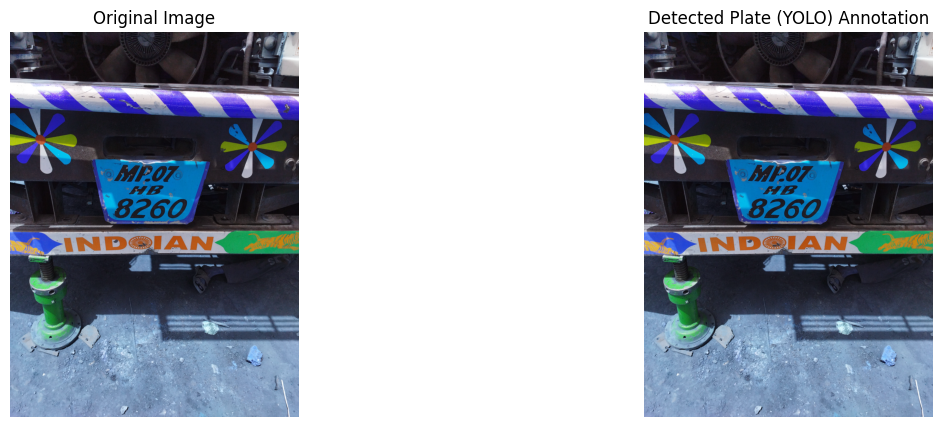

No number plate detected in the image.


In [65]:
main()

In [61]:
import cv2
from ultralytics import YOLO
import easyocr
import torch

# Load YOLO model (using the downloaded generic model)
# Replace 'yolov8n.pt' with 'license_plate_detector.pt' if you have a specialized model.
model = YOLO('yolov8n.pt')   # Changed to yolov8n.pt
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

def detect_plate_yolo(image):
    """YOLOv8 Plate Detection (replaces contour method) with aspect ratio filtering"""
    results = model(image, conf=0.25, verbose=False)

    candidate_plates = []
    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            cls = int(box.cls[0].item()) # Get the class ID
            label = model.names[cls]     # Get the class label from the model

            width = x2 - x1
            height = y2 - y1

            # Apply heuristics: aspect ratio and minimum size
            # Typical license plates have aspect ratios between ~1.5 and ~6.0 (width/height)
            # and should not be too small.
            if width > 50 and height > 20 and 1.5 < (width / height) < 6.0:
                candidate_plates.append((conf, x1, y1, x2, y2, label))

    if not candidate_plates:
        return None, image # No suitable plate candidates found after filtering

    # Sort candidates by confidence and pick the best one
    # If multiple objects meet the criteria, the most confident one is chosen.
    candidate_plates.sort(key=lambda x: x[0], reverse=True)
    best_conf, x1, y1, x2, y2, label = candidate_plates[0]

    # Draw bounding box for the best candidate
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(image, f"{label} {best_conf:.2f}", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Crop plate
    plate = image[y1:y2, x1:x2]
    return plate, image

# OCR on cropped plate (same as before, but using EasyOCR)
def ocr_plate_easyocr(plate):
    if plate is None:
        return "No plate"
    result = reader.readtext(plate, detail=0, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')
    return ''.join(result).strip()


In [52]:
%%writefile preprocessing.py
import cv2
import numpy as np

def preprocess_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None, None, None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    return image, gray, blurred

Overwriting preprocessing.py


In [53]:
%%writefile edge_contour.py
import cv2

def detect_edges_and_contours(blurred):
    edged = cv2.Canny(blurred, 30, 200)
    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:30]
    return edged, contours

Overwriting edge_contour.py


In [54]:
%%writefile roi_detection.py
import cv2

def detect_plate_roi(image, contours):
    plate_cnt = None
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            plate_cnt = approx
            break
    if plate_cnt is None:
        return None, image
    x, y, w, h = cv2.boundingRect(plate_cnt)
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 3)
    plate_roi = image[y:y+h, x:x+w]
    return plate_roi, image

Overwriting roi_detection.py


In [55]:
%%writefile ocr_module.py
import cv2
import pytesseract
import re

# Removed or commented out Windows-specific Tesseract path for Colab environment
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\winpath.exe'

def perform_ocr(plate_image):
    if plate_image is None:
        return "No plate found"
    gray_plate = cv2.cvtColor(plate_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray_plate, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    text = pytesseract.image_to_string(thresh, config=custom_config).strip()
    cleaned_text = re.sub(r'[^A-Z0-9]', '', text)
    return cleaned_text

Overwriting ocr_module.py



Final Detected Number Plate: No plate found


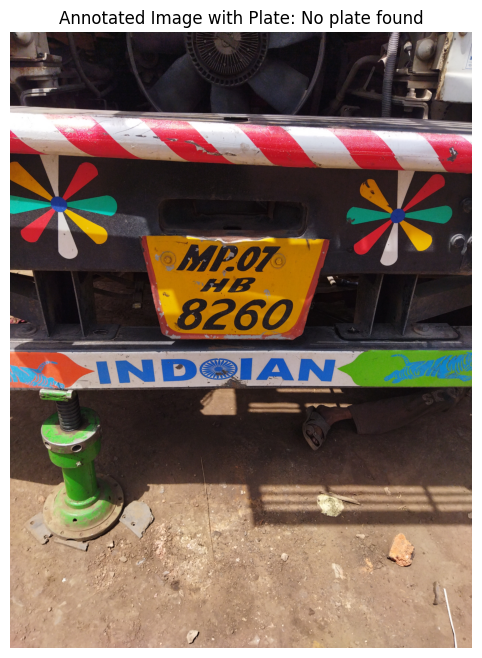

In [66]:
from preprocessing import preprocess_image
from edge_contour import detect_edges_and_contours
from roi_detection import detect_plate_roi
from ocr_module import perform_ocr
import matplotlib.pyplot as plt
import cv2 # Import cv2 for image operations like cv2.cvtColor

image_path = "//content/Datacluster_number_plates (73).jpg"   # Change to your test image

original, gray, blurred = preprocess_image(image_path)

if original is None:
    print("Error: Preprocessing failed, cannot proceed.")
else:
    edged, contours = detect_edges_and_contours(blurred)
    plate_roi, annotated = detect_plate_roi(original.copy(), contours)
    text = perform_ocr(plate_roi)

    print(f"\nFinal Detected Number Plate: {text}")

    # Display final annotated image using matplotlib
    if annotated is not None:
        plt.figure(figsize=(10, 8))
        # Convert BGR to RGB for matplotlib display
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        plt.imshow(annotated_rgb)
        plt.title(f"Annotated Image with Plate: {text}")
        plt.axis('off')
        plt.show()
    else:
        print("No annotated image to display.")
